# Ajuste P6 Michelson

In [2]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
import math
#from acrylic import Color

In [3]:
df = pd.read_excel("OpticaP6mas.xlsx", sheet_name="MICHELSONFORMATTED")

In [4]:
Pup = df["Pup"].to_numpy()
deltaMup = df["DeltaMup"].to_numpy()
deltaNup = deltaMup * (632.8 * 10**-9)/(2*10*10**-3)

Pdown = df["Pdown"].to_numpy()
deltaMdown = df["DeltaMdown"].to_numpy()
deltaNdown = deltaMdown * (632.8 * 10**-9)/(2*10*10**-3)

Puplist = []
auxList = np.array([])
for x in Pup:
    if not math.isnan(x):
        auxList = np.append(auxList,x)
    else :
        Puplist.append(auxList)
        auxList = []

Pdownlist = []
auxList = np.array([])
for x in Pdown:
    if not math.isnan(x):
        auxList = np.append(auxList,x)
    else :
        Pdownlist.append(auxList)
        auxList = []

deltaNuplist = []
auxList = np.array([])
for x in deltaNup:
    if not math.isnan(x):
        auxList = np.append(auxList,x)
    else :
        deltaNuplist.append(auxList)
        auxList = []

deltaNdownlist = []
auxList = np.array([])
for x in deltaNdown:
    if not math.isnan(x):
        auxList = np.append(auxList,x)
    else :
        deltaNdownlist.append(auxList)
        auxList = []

In [5]:
deltaMuplist = []
auxList = np.array([])
for x in deltaMup:
    if not math.isnan(x):
        auxList = np.append(auxList,x)
    else :
        deltaMuplist.append(auxList)
        auxList = []

deltaMdownlist = []
auxList = np.array([])
for x in deltaMdown:
    if not math.isnan(x):
        auxList = np.append(auxList,x)
    else :
        deltaMdownlist.append(auxList)
        auxList = []

In [6]:
regresionUplist = []
for x,y in zip(Puplist, deltaNuplist):
    regresionUplist.append(scipy.stats.linregress(x,y))

regresionDownlist = []
for x,y in zip(Pdownlist, deltaNdownlist):
    regresionDownlist.append(scipy.stats.linregress(x,y))


In [7]:
#here go the colors

colorspace = np.linspace(0,1,num=len(Puplist))
spaceup = colormaps["coolwarm"]
spacedown = colormaps["coolwarm"]
gradientUp = spaceup(colorspace)
gradientDown = spacedown(colorspace)

#hueUp = np.interp(np.linspace(0,100,len(Puplist)),(0,100),(0,60))
#lUp = np.interp(np.linspace(0,100,len(Puplist)),(0,100),(100,50))
#gradientUp = [Color(hsv=[c,l,100]) for c,l in zip(hueUp,lUp)]

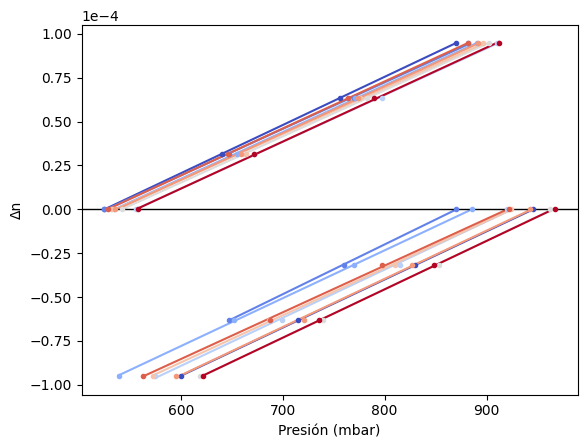

In [8]:
for x,y,R,c in zip(Puplist,deltaNuplist,regresionUplist, gradientUp):
    plt.errorbar(x,y,marker = ".", ls = "", xerr = 0.2886751346, color = c)
    plt.plot(x,R.slope*x + R.intercept, color = c)

for x,y,R,c in zip(Pdownlist,deltaNdownlist,regresionDownlist, gradientDown):
    plt.errorbar(x,y,marker = ".", ls = "", xerr = 0.2886751346, color = c)
    plt.plot(x,R.slope*x + R.intercept, color = c)

plt.xlabel("Presión (mbar)")
plt.ylabel("Δn")

plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.axhline(0, color='black', lw = 1)

plt.savefig(fname="test.png",dpi=400)

In [12]:
bigList = regresionUplist + regresionDownlist

slopes = [x.slope for x in bigList]
averageSlope = np.average(slopes)

uncertaintiesSq = [x.stderr**2 for x in bigList]
finalUncertainty = np.sqrt(np.sum(uncertaintiesSq))/np.sqrt(len(uncertaintiesSq))


pearsons = [x.rvalue**2 for x in bigList]
averagePearson = np.average(pearsons)


intercepts = [x.intercept for x in bigList]
averageIntercept = np.average(intercepts)

interceptUncertaintiesSq = [x.intercept_stderr**2 for x in bigList]
finalInterceptUncertainty = np.sqrt(np.sum(interceptUncertaintiesSq))/np.sqrt(len(interceptUncertaintiesSq))


print("deltan/deltap = " + str(averageSlope) + " ± " + str(finalUncertainty) + "mbar^-1")
print("b = " + str(averageIntercept) + " pm " + str(finalInterceptUncertainty))

print("n ambiental = " + str(1 + averageSlope*1013))

print("R^2 promedio = " + str(averagePearson))


deltan/deltap = 2.702747306947947e-07 ± 3.5443328588810594e-09mbar^-1
b = -0.00020112571154228738 pm 2.687633416619552e-06
n ambiental = 1.000273788302194
R^2 promedio = 0.9996595124796146
